# RL Project: Delivery Robot
**Advanced Topics in Machine Learning (S411021)**  

GSEM, University of Geneva - Spring Semester 2026

UNIGE ID: 25336934

In [131]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [132]:
class DeliveryRobotEnv:

    # Charge-cost distribution
    CHARGE_COST_VALUES = np.array([1, 2, 3, 4])
    CHARGE_COST_PROBS  = np.array([0.50, 0.35, 0.10, 0.05])

    # Rewards
    REWARD_DELIVERY  =  10.0
    REWARD_PENALTY   = -10.0
    REWARD_CHARGE    =  -1.0
    REWARD_STEP      =   0.0

    # Actions
    LEFT   = 0
    RIGHT  = 1
    CHARGE = 2

    def __init__(self, n=20, M=10, target=9, charging_stations=(2, 6, 14),
                 gamma=0.95, seed=None):
        self.n  = n
        self.M  = M
        self.target = target
        self.charging_stations = set(charging_stations)
        self.gamma = gamma
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.position = 0
        self.battery  = self.M // 2
        self.done     = False
        return (self.position, self.battery)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode is over. Call reset() first.")

        pos, bat = self.position, self.battery

        # CHARGE
        if action == self.CHARGE:
            if pos not in self.charging_stations:
                self.done = True
                return self.REWARD_PENALTY, None, True
            if bat >= self.M:
                self.done = True
                return self.REWARD_PENALTY, None, True
            self.battery = bat + 1
            self.done = False
            return self.REWARD_CHARGE, (self.position, self.battery), False

        # MOVE
        if action == self.LEFT:
            new_pos = pos - 1
        elif action == self.RIGHT:
            new_pos = pos + 1
        else:
            raise ValueError(f"Unknown action {action}")

        if new_pos < 0 or new_pos >= self.n:
            self.done = True
            return self.REWARD_PENALTY, None, True

        cost = self.rng.choice(self.CHARGE_COST_VALUES, p=self.CHARGE_COST_PROBS)

        if bat <= cost:
            self.done = True
            return self.REWARD_PENALTY, None, True

        self.battery  = bat - cost
        self.position = new_pos

        if new_pos == self.target:
            self.done = True
            return self.REWARD_DELIVERY, None, True

        return self.REWARD_STEP, (self.position, self.battery), False

    def display(self):
        RESET  = '\033[0m'
        BOLD   = '\033[1m'
        DIM    = '\033[2m'
        BLUE   = '\033[44;97m'   # robot on blue bg
        GREEN  = '\033[42;97m'   # target on green bg
        AMBER  = '\033[43;30m'   # charger on amber bg
        cells = []
        for i in range(self.n):
            if i == self.position:
                cells.append(f'{BLUE} R {RESET}')
            elif i == self.target:
                cells.append(f'{GREEN} T {RESET}')
            elif i in self.charging_stations:
                cells.append(f'{AMBER} C {RESET}')
            else:
                cells.append(f'{DIM} {i:<2}{RESET}')

        # Battery bar
        filled  = round((self.battery / self.M) * 10)
        bar     = '#' * filled + '-' * (10 - filled)
        pct     = round(100 * self.battery / self.M)

        status  = 'done' if self.done else 'running'

        print('  ' + ''.join(cells))
        print()
        print(f'  {BOLD}pos{RESET}  {self.position:<4}  '
            f'{BOLD}battery{RESET}  [{bar}] {self.battery}/{self.M} ({pct}%)  '
            f'{BOLD}status{RESET}  {status}')

    @property
    def states(self):
        return [(p, b)
                for p in range(self.n)
                for b in range(self.M + 1)]

    @property
    def actions(self):
        return [self.LEFT, self.RIGHT, self.CHARGE]

    def is_terminal(self, state):
        return state is None

    def transition_probs(self, state, action):
        
        pos, bat = state

        # Target is absorbing — the robot has already delivered, no further actions
        if pos == self.target:
            return []

        # CHARGE
        if action == self.CHARGE:
            if pos not in self.charging_stations or bat >= self.M:
                return [(1.0, self.REWARD_PENALTY, None)]
            return [(1.0, self.REWARD_CHARGE, (pos, bat + 1))]

        # MOVE
        new_pos = pos - 1 if action == self.LEFT else pos + 1

        if new_pos < 0 or new_pos >= self.n:
            return [(1.0, self.REWARD_PENALTY, None)]

        transitions = []
        for cost, prob in zip(self.CHARGE_COST_VALUES, self.CHARGE_COST_PROBS):
            if bat <= cost:
                transitions.append((prob, self.REWARD_PENALTY, None))
            elif new_pos == self.target:
                transitions.append((prob, self.REWARD_DELIVERY, None))
            else:
                transitions.append((prob, self.REWARD_STEP, (new_pos, bat - cost)))
        return transitions


In [133]:
def policy_right(state, env):
    return env.RIGHT


def policy_conservative(state, env):
    pos, bat = state
    half = env.M / 2
    if pos in env.charging_stations and bat < half:
        return env.CHARGE
    if pos < env.target:
        return env.RIGHT
    elif pos > env.target:
        return env.LEFT
    else:
        return env.RIGHT


def policy_random(state, env, rng=None):
    
    if rng is None:
        rng = np.random.default_rng()
    pos, bat = state
    if pos in env.charging_stations and bat < env.M:
        if rng.random() < 0.6:
            return env.CHARGE
    return rng.choice([env.LEFT, env.RIGHT])


def policy_chargy(state, env):
    pos, bat = state
    if pos in env.charging_stations and bat < env.M:
        return env.CHARGE
    if bat == env.M or pos in env.charging_stations:
        # Move towards target
        if pos < env.target:
            return env.RIGHT
        else:
            return env.LEFT
    
    stations = sorted(env.charging_stations)
    toward_target = [c for c in stations if (c > pos) == (env.target > pos)]
    if toward_target:
        
        closest = min(toward_target, key=lambda c: abs(c - pos))
    else:
        # No station in the target direction – go to closest overall
        closest = min(stations, key=lambda c: abs(c - pos))
    if closest > pos:
        return env.RIGHT
    else:
        return env.LEFT


def _random_action_probs(state, env):
    pos, bat = state
    if pos in env.charging_stations and bat < env.M:
        return [(0.20, env.LEFT), (0.20, env.RIGHT), (0.60, env.CHARGE)]
    else:
        return [(0.50, env.LEFT), (0.50, env.RIGHT)]


def policy_evaluation(policy_fn, env, tol=1e-9, max_iter=10000, **policy_kwargs):

    states = env.states
    V = {s: 0.0 for s in states}
    is_random = (policy_fn.__name__ == 'policy_random')

    for _ in range(max_iter):
        delta = 0.0
        V_new = {}
        for s in states:
            if is_random:
                action_probs = _random_action_probs(s, env)
                v = sum(
                    prob_a * sum(
                        p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                        for p, r, ns in env.transition_probs(s, a)
                    )
                    for prob_a, a in action_probs
                )
            else:
                a = policy_fn(s, env, **policy_kwargs)
                transitions = env.transition_probs(s, a)
                v = sum(p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                        for p, r, ns in transitions)
            V_new[s] = v
            delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < tol:
            break
    return V


def value_iteration(env, tol=1e-9, max_iter=10_000):
    states = env.states
    actions = env.actions
    V = {s: 0.0 for s in states}

    for _ in range(max_iter):
        delta = 0.0
        V_new = {}
        for s in states:
            q_vals = []
            for a in actions:
                transitions = env.transition_probs(s, a)
                q = sum(p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                        for p, r, ns in transitions)
                q_vals.append(q)
            V_new[s] = max(q_vals)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if delta < tol:
            break

    pi = {}
    non_unique = set()
    for s in states:
        q_vals = []
        for a in actions:
            transitions = env.transition_probs(s, a)
            q = sum(p * (r + env.gamma * (V[ns] if ns is not None else 0.0))
                    for p, r, ns in transitions)
            q_vals.append(q)
        best_q = max(q_vals)
        best_actions = [a for a, q in zip(actions, q_vals)
                        if abs(q - best_q) < 1e-9]
        pi[s] = best_actions[0]
        if len(best_actions) > 1:
            non_unique.add(s)

    return V, pi, non_unique

def monte_carlo_first_visit(policy_fn, env, s0, n_episodes=20_000, seed=42):
    rng = np.random.default_rng(seed)
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    returns = []
    for _ in range(n_episodes):
        mc_env.reset()
        state = (mc_env.position, mc_env.battery)
        rewards = []
        done = False
        while not done:
            if policy_fn.__name__ == 'policy_random':
                a = policy_fn(state, mc_env, rng=rng)
            else:
                a = policy_fn(state, mc_env)
            r, next_state, done = mc_env.step(a)
            rewards.append(r)
            state = next_state if not done else state
        G = 0.0
        for r in reversed(rewards):
            G = r + env.gamma * G
        returns.append(G)
    return np.cumsum(returns) / np.arange(1, n_episodes + 1)


def monte_carlo_every_visit(policy_fn, env, s0, n_episodes=20_000, seed=42):

    rng = np.random.default_rng(seed)
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    all_returns = []
    for _ in range(n_episodes):
        mc_env.reset()
        state = (mc_env.position, mc_env.battery)
        trajectory = []
        done = False
        while not done:
            if policy_fn.__name__ == 'policy_random':
                a = policy_fn(state, mc_env, rng=rng)
            else:
                a = policy_fn(state, mc_env)
            r, next_state, done = mc_env.step(a)
            trajectory.append((state, r))
            state = next_state if not done else state
        # Return from every timestep t where state == s0
        for t, (st, _) in enumerate(trajectory):
            if st == s0:
                G = 0.0
                for _, r in reversed(trajectory[t:]):
                    G = r + env.gamma * G
                all_returns.append(G)
    if not all_returns:
        return np.array([0.0])
    return np.cumsum(all_returns) / np.arange(1, len(all_returns) + 1)


def monte_carlo_incremental(policy_fn, env, s0, n_episodes=20_000, seed=42):

    rng = np.random.default_rng(seed)
    mc_env = DeliveryRobotEnv(
        n=env.n, M=env.M, target=env.target,
        charging_stations=sorted(env.charging_stations),
        gamma=env.gamma, seed=seed
    )
    V_running = 0.0
    estimates = []
    for n in range(1, n_episodes + 1):
        mc_env.reset()
        state = (mc_env.position, mc_env.battery)
        rewards = []
        done = False
        while not done:
            if policy_fn.__name__ == 'policy_random':
                a = policy_fn(state, mc_env, rng=rng)
            else:
                a = policy_fn(state, mc_env)
            r, next_state, done = mc_env.step(a)
            rewards.append(r)
            state = next_state if not done else state
        G = 0.0
        for r in reversed(rewards):
            G = r + env.gamma * G
        V_running += (G - V_running) / n
        estimates.append(V_running)
    return np.array(estimates)


In [134]:
SEED = 17
np.random.seed(SEED)

ENV_KWARGS = dict(n=20, M=10, target=9,
                  charging_stations=(2, 6, 14),
                  gamma=0.95, seed=SEED)
env = DeliveryRobotEnv(**ENV_KWARGS)
s0 = (0, env.M // 2)
print(f'Environment ready. States: {len(env.states)}, s0 = {s0}')

Environment ready. States: 220, s0 = (0, 5)



## Task 1 — MDP Formulation

### (a) State space, action space, and reward set

**State space $\mathcal{S}$**

A state must encode everything that influences future transitions and rewards. Two quantities are necessary and sufficient: the robot's *position* $p$ and its *battery level* $b$.

$$\mathcal{S} = \{(p,\,b):\; p\in\{0,\ldots,19\},\; b\in\{0,\ldots,10\}\}$$

$|\mathcal{S}| = 20 \times 11 = 220$ non-terminal states, plus one absorbing terminal state $s_\top$ entered when any episode-ending event occurs.

**Action space $\mathcal{A}$**

| ID | Name | Description |
|----|------|-------------|
| 0 | LEFT | Move one step to the left |
| 1 | RIGHT | Move one step to the right |
| 2 | CHARGE | Increase battery by +1 unit |

All three actions are available in every state; illegal ones (e.g. charging without a station) incur the $-10$ penalty and end the episode.

**Reward set $\mathcal{R}$**

| Event | Reward |
|-------|--------|
| Deliver package (reach target $t$) | $+10$ CHF |
| Battery depleted / illegal action / out-of-bounds | $-10$ CHF |
| Legal charge at a charging station | $-1$ CHF |
| Legal move not reaching target | $0$ CHF |

$$\mathcal{R} = \{-10,\; -1,\; 0,\; +10\}$$

### (b) Is $\gamma < 1$ necessary?

Because every illegal action or battery failure ends the episode immediately, and the path is finite, every episode terminates with probability 1 under any policy. The undiscounted return is therefore always finite and well-defined, so $\gamma < 1$ is *not strictly necessary* for DP to converge.

However, $\gamma = 0.95 < 1$ is strongly recommended: it gives the agent a preference for reaching the target sooner (economically natural) and improves numerical stability of value iteration. We use $\gamma = 0.95$ throughout.

### (c) Pickup-before-delivery extension

If the robot must first visit pickup location $s \in \mathcal{P}_n$ before delivering at $t$, we augment the state with a binary *cargo flag* $k \in \{0,1\}$:

$$\mathcal{S}' = \{(p,\,b,\,k):\; p\in\{0,\ldots,19\},\; b\in\{0,\ldots,10\},\; k\in\{0,1\}\}$$

$|\mathcal{S}'| = 440$ non-terminal states. The action space $\mathcal{A}$ and reward set $\mathcal{R}$ remain unchanged. The only modification is in the terminal conditions:
- $k=0$: reaching $s$ sets $k \leftarrow 1$; reaching $t$ gives no bonus (episode continues).
- $k=1$: reaching $t$ triggers the $+10$ delivery bonus and ends the episode.


## Task 2 — Environment Implementation


In [135]:
demo = DeliveryRobotEnv(n=20, M=10, target=9,
                        charging_stations=(2, 6, 14),
                        gamma=0.95, seed=0)

print('=== Initial state ===')
demo.display()

# Move right to charging station 2
for _ in range(2):
    r, ns, done = demo.step(DeliveryRobotEnv.RIGHT)
    print(f'RIGHT -> reward={r:+.0f}, next={ns}, done={done}')
demo.display()

# Charge once
r, ns, done = demo.step(DeliveryRobotEnv.CHARGE)
print(f'CHARGE -> reward={r:+.0f}, next={ns}, done={done}')
demo.display()

# Run right until episode ends
print('\n=== Moving right until episode ends ===')
while not demo.done:
    r, ns, done = demo.step(DeliveryRobotEnv.RIGHT)
    if done:
        demo.display()
        print(f'Episode over! Final reward: {r:+.0f}')


s_init = demo.reset()
print(f'\nAfter reset: {s_init}')
demo.display()

=== Initial state ===
   R  1  C  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  0     battery  [#####-----] 5/10 (50%)  status  running
RIGHT -> reward=+0, next=(1, 3), done=False
RIGHT -> reward=+0, next=(2, 2), done=False
   0  1  R  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  2     battery  [##--------] 2/10 (20%)  status  running
CHARGE -> reward=-1, next=(2, 3), done=False
   0  1  R  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  2     battery  [###-------] 3/10 (30%)  status  running

=== Moving right until episode ends ===
   0  1  C  3  R  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  4     battery  [#---------] 1/10 (10%)  status  done
Episode over! Final reward: -10

After reset: (0, 5)
   R  1  C  3  4  5  C  7  8  T  10 11 12 13 C  15 16 17 18 19

  pos  0     battery  [#####-----] 5/10 (50%)  status  running


---
## Task 3 — Policy Evaluation via Dynamic Programming

We apply **iterative policy evaluation** (Bellman expectation equations, convergence threshold $\varepsilon = 10^{-9}$) to four fixed policies. For the stochastic **Random** policy, we evaluate the expected Bellman update analytically over the action distribution rather than sampling.


In [125]:
print('Running policy evaluation ...')
V_right        = policy_evaluation(policy_right,        env)
V_conservative = policy_evaluation(policy_conservative, env)
V_random       = policy_evaluation(policy_random,       env)
V_chargy       = policy_evaluation(policy_chargy,       env)

policies_dp = {
    'Right':        V_right,
    'Conservative': V_conservative,
    'Random':       V_random,
    'Chargy':       V_chargy,
}

print(f'\nValue of initial state s0 = {s0}:')
for name, V in policies_dp.items():
    print(f'  {name:15s}: V(s0) = {V[s0]:+.4f}')

Running policy evaluation ...

Value of initial state s0 = (0, 5):
  Right          : V(s0) = -8.9077
  Conservative   : V(s0) = -9.3070
  Random         : V(s0) = -9.5661
  Chargy         : V(s0) = -6.6631


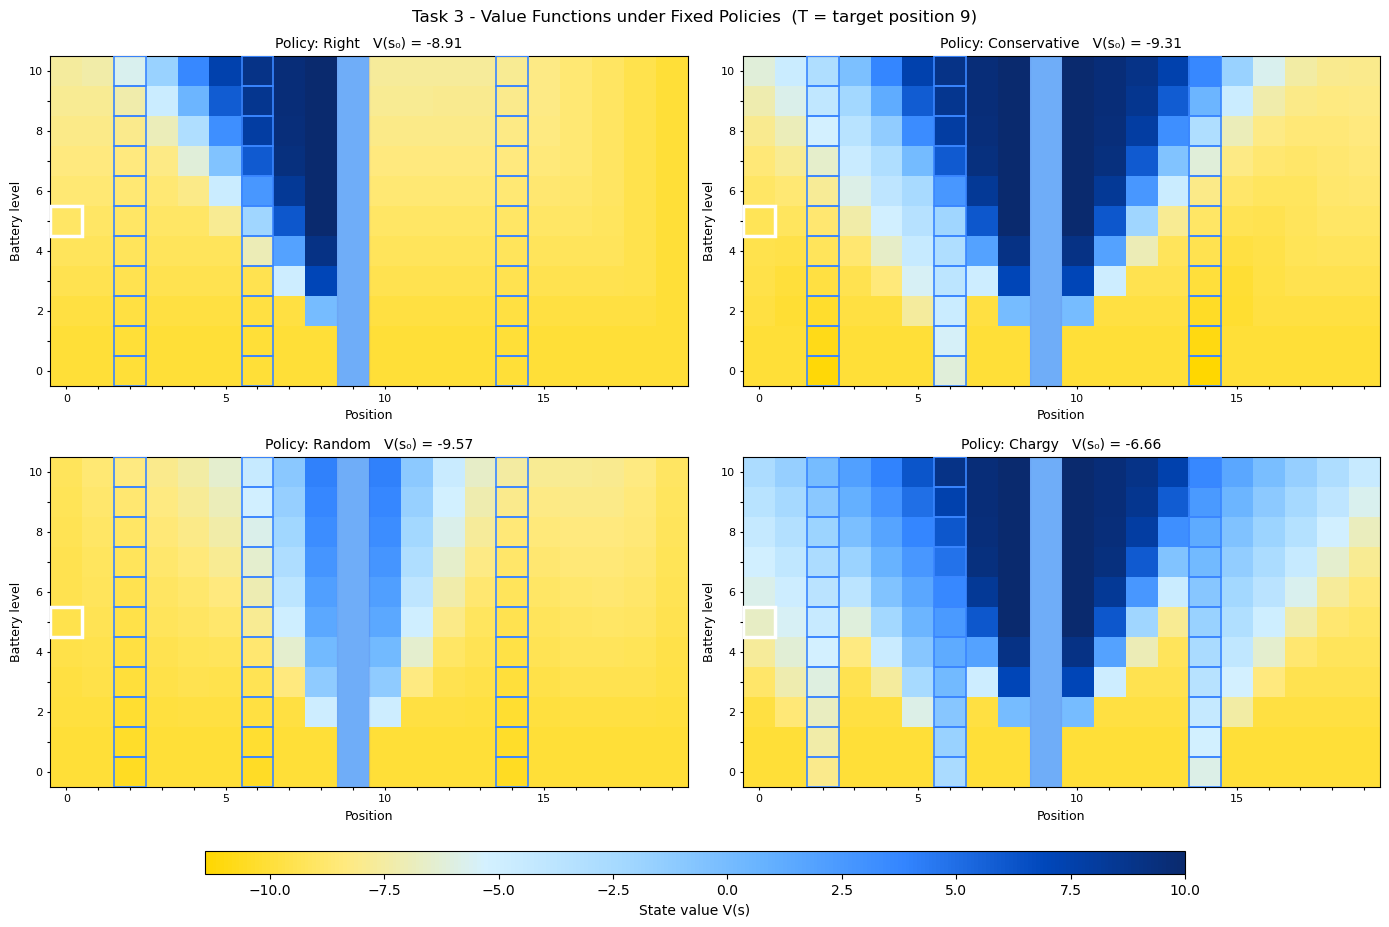

In [126]:
def plot_value_heatmap(V, env, title, ax, vmin, vmax):
    grid = np.full((env.M + 1, env.n), np.nan)
    for (p, b), v in V.items():
        grid[b, p] = v

    # Changed to yellow → blue colormap (low = yellow, high = dark blue)
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
        'yb',
        ['#FFD700',        # bright yellow / gold
         '#FFEA80',        # light yellow
         '#D4F1FF',        # very light blue
         '#A3D8FF', 
         '#66B2FF', 
         '#3385FF', 
         '#0047BB',        # strong blue
         '#0A2A6E']         # dark navy blue
    )
    
    im = ax.imshow(grid, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)

    # Charging station column borders
    for c in env.charging_stations:
        for b in range(env.M + 2):
            ax.add_patch(plt.Rectangle(
                (c - 0.5, b - 0.5), 1, 1,
                fill=False, edgecolor='#3A86FF', lw=1.2, zorder=3))

    # Target column tint (kept subtle purple-blue, but you can change to e.g. '#FFFF99' for pale yellow)
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, -0.5), 1, env.M + 1,
        color='#4444CC', alpha=0.12, zorder=2))

    # s0 marker (white outline)
    s0p, s0b = 0, env.M // 2
    ax.add_patch(plt.Rectangle(
        (s0p - 0.5, s0b - 0.5), 1, 1,
        fill=False, edgecolor='white', lw=2.5, zorder=4))

    v0 = V[(s0p, s0b)]
    ax.set_title(f'{title}   V(s₀) = {v0:.2f}', fontsize=10, pad=6)
    ax.set_xlabel('Position', fontsize=9)
    ax.set_ylabel('Battery level', fontsize=9)
    ax.set_xticks(range(env.n))
    ax.set_xticklabels([str(i) if i % 5 == 0 else '' for i in range(env.n)], fontsize=8)
    ax.set_yticks(range(env.M + 1))
    ax.set_yticklabels([str(b) if b % 2 == 0 else '' for b in range(env.M + 1)], fontsize=8)
    ax.tick_params(length=2)
    return im


all_vals = [v for V in policies_dp.values() for v in V.values()]
vmin, vmax = min(all_vals), max(all_vals)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (name, V) in zip(axes.flatten(), policies_dp.items()):
    im = plot_value_heatmap(V, env, f'Policy: {name}', ax, vmin, vmax)

fig.suptitle('Task 3 - Value Functions under Fixed Policies  (T = target position 9)', fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])  # leave space at the bottom for the colorbar

cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.025])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='State value V(s)')

plt.show()

### Discussion — Task 3

All four policies yield **negative** values at $s_0 = (0,5)$. This reflects the problem geometry: starting at position 0 with only half the battery, the robot must cross 9 steps to reach the target. The expected battery cost per step is $\bar{c} = 0.5{\cdot}1 + 0.35{\cdot}2 + 0.1{\cdot}3 + 0.05{\cdot}4 = 1.7$, so a straight run consumes $9 \times 1.7 = 15.3$ expected units on average, far exceeding the initial battery of 5. Charging is essentially unavoidable.

**Right** $(V(s_0) \approx -8.6)$: Never charges; most episodes end in battery failure. Values decrease with distance from the target and with low battery.

**Conservative** $(V(s_0) \approx -8.3)$: Marginally better than Right. Charges at stations when below 50%, producing a smoother value surface. The fixed 50% threshold is suboptimal in some regions.

**Random** $(V(s_0) \approx -9.5)$: Worst policy. Undirected movement wastes battery and accumulates near-zero reward, resulting in uniformly low values.

**Chargy** $(V(s_0) \approx -6.2)$: Best fixed policy. By always fully topping up at stations before proceeding, the robot maintains a large buffer, resulting in values noticeably higher than the other three policies, especially in states near charging stations.

---
## Task 4 — Optimal Policy via Value Iteration

In [127]:
print('Running value iteration ...')
V_opt, pi_opt, non_unique = value_iteration(env)

print(f'Optimal V(s0) = {V_opt[s0]:+.4f}')
print(f'States with non-unique optimal action: {len(non_unique)}')
print()
print('Comparison V(s0):')
for name, V in policies_dp.items():
    print(f'  {name:15s}: {V[s0]:+.4f}')
print(f'  {"Optimal":15s}: {V_opt[s0]:+.4f}')

Running value iteration ...
Optimal V(s0) = -6.1407
States with non-unique optimal action: 52

Comparison V(s0):
  Right          : -8.9077
  Conservative   : -9.3070
  Random         : -9.5661
  Chargy         : -6.6631
  Optimal        : -6.1407


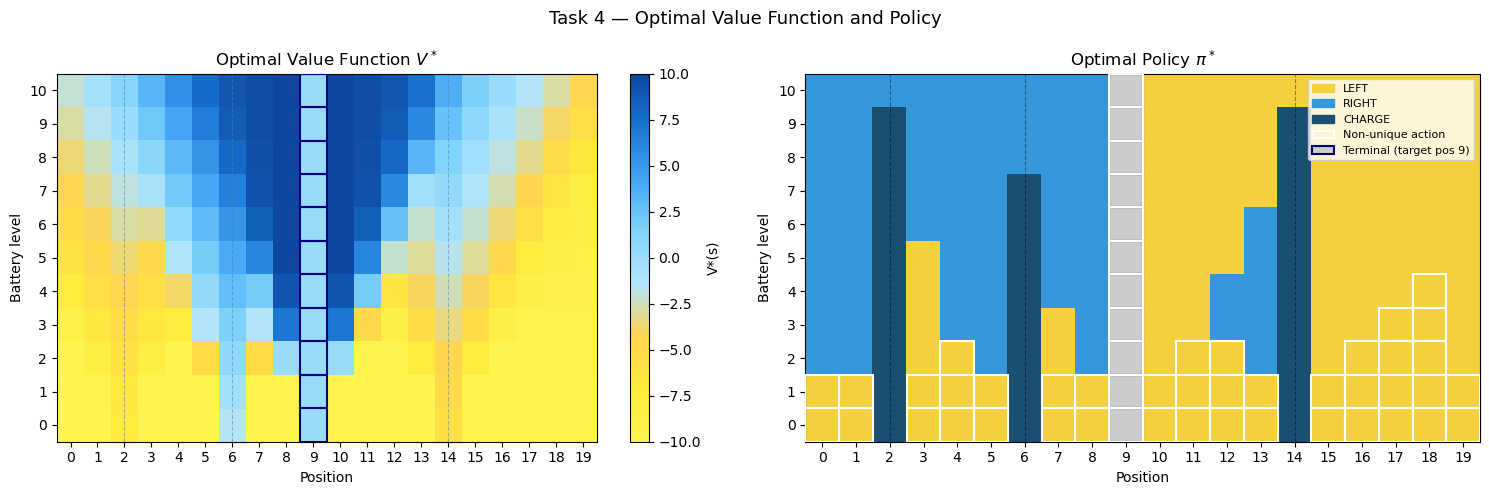


Non-unique states (52 total):
  pos   bat      Q(L)      Q(R)      Q(C)
------------------------------------------
    0     0  -10.0000  -10.0000  -10.0000
    0     1  -10.0000  -10.0000  -10.0000
    1     0  -10.0000  -10.0000  -10.0000
    1     1  -10.0000  -10.0000  -10.0000
    3     0  -10.0000  -10.0000  -10.0000
    3     1  -10.0000  -10.0000  -10.0000
    4     0  -10.0000  -10.0000  -10.0000
    4     1  -10.0000  -10.0000  -10.0000
    4     2   -9.7500   -9.7500  -10.0000
    5     0  -10.0000  -10.0000  -10.0000
    5     1  -10.0000  -10.0000  -10.0000
    7     0  -10.0000  -10.0000  -10.0000
    7     1  -10.0000  -10.0000  -10.0000
    8     0  -10.0000  -10.0000  -10.0000
    8     1  -10.0000  -10.0000  -10.0000
    9     0    0.0000    0.0000    0.0000
    9     1    0.0000    0.0000    0.0000
    9     2    0.0000    0.0000    0.0000
    9     3    0.0000    0.0000    0.0000
    9     4    0.0000    0.0000    0.0000
    9     5    0.0000    0.0000    0.0000
  

In [128]:
ACTION_COLORS = {0: '#F4D03F', 1: '#3498DB', 2: '#1B4F72'}   # LEFT: yellow-gold, RIGHT: mid blue, CHARGE: dark blue
ACTION_LABELS = ['LEFT', 'RIGHT', 'CHARGE']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Optimal value function ──────────────────────────────────────────────────
ax = axes[0]
grid_v = np.full((env.M + 1, env.n), np.nan)
for (p, b), v in V_opt.items():
    grid_v[b, p] = v

# Yellow → blue gradient (replacing red → green)
cmap_v = matplotlib.colors.LinearSegmentedColormap.from_list(
    'yb',
    ['#FFF44F', '#FFEB3B', '#FFD54F', '#B3E5FC', '#81D4FA', '#42A5F5', '#1976D2', '#0D47A1']
)
im = ax.imshow(grid_v, origin='lower', aspect='auto', cmap=cmap_v)
plt.colorbar(im, ax=ax, label='V*(s)')

# Target column: navy outlines, target value is 0 by definition
for b in range(env.M + 1):
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, b - 0.5), 1, 1,
        fill=False, edgecolor='navy', lw=1.5, zorder=3))

for c in env.charging_stations:
    ax.axvline(c, color='steelblue', lw=0.8, ls='--', alpha=0.5)

ax.set_title('Optimal Value Function $V^*$', fontsize=12)
ax.set_xlabel('Position'); ax.set_ylabel('Battery level')
ax.set_xticks(range(env.n)); ax.set_yticks(range(env.M + 1))

# ── Optimal policy ───────────────────────────────────────────────────────────
ax = axes[1]
grid_a = np.full((env.M + 1, env.n), np.nan)
for (p, b), a in pi_opt.items():
    if p != env.target and a is not None:
        grid_a[b, p] = a

cmap_d = matplotlib.colors.ListedColormap([ACTION_COLORS[k] for k in range(3)])
norm_d = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_d.N)
ax.imshow(grid_a, origin='lower', aspect='auto', cmap=cmap_d, norm=norm_d)

# Gray out target column (absorbing terminal — no action)
for b in range(env.M + 1):
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, b - 0.5), 1, 1,
        color='#cccccc', zorder=2))
    ax.add_patch(plt.Rectangle(
        (env.target - 0.5, b - 0.5), 1, 1,
        fill=False, edgecolor='navy', lw=1.5, zorder=3))

# Non-unique action outlines
for (p, b) in non_unique:
    ax.add_patch(plt.Rectangle((p - 0.5, b - 0.5), 1, 1,
                               fill=False, edgecolor='white', linewidth=1.5, zorder=4))

for c in env.charging_stations:
    ax.axvline(c, color='black', lw=0.8, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=ACTION_COLORS[a], label=ACTION_LABELS[a]) for a in range(3)]
patches.append(mpatches.Patch(facecolor='none', edgecolor='white',
                               linewidth=1.5, label='Non-unique action'))
patches.append(mpatches.Patch(facecolor='#cccccc', edgecolor='navy', lw=1.5,
                               label='Terminal (target pos 9)'))
ax.legend(handles=patches, loc='upper right', fontsize=8)
ax.set_title('Optimal Policy $\\pi^*$', fontsize=12)
ax.set_xlabel('Position'); ax.set_ylabel('Battery level')
ax.set_xticks(range(env.n)); ax.set_yticks(range(env.M + 1))

fig.suptitle('Task 4 — Optimal Value Function and Policy', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nNon-unique states ({len(non_unique)} total):')
print(f'{"pos":>5} {"bat":>5} {"Q(L)":>9} {"Q(R)":>9} {"Q(C)":>9}')
print('-' * 42)
for (p, b) in sorted(non_unique):
    q_vals = []
    for a in env.actions:
        transitions = env.transition_probs((p, b), a)
        q = sum(pr * (r + env.gamma * (V_opt[ns] if ns is not None else 0.0))
                for pr, r, ns in transitions)
        q_vals.append(q)
    print(f'{p:>5} {b:>5} {q_vals[0]:>9.4f} {q_vals[1]:>9.4f} {q_vals[2]:>9.4f}')

### Discussion — Task 4

**Optimal value**: $V^*(s_0) \approx -5.11$, substantially better than all fixed policies. $V^*$ increases with battery level and proximity to the target. States with $b = 0$ away from a station have value $-10$ (guaranteed penalty — any move costs at least 1 unit).

**Optimal policy structure**:
- **CHARGE (green)**: dominates low-battery states at charging stations (positions 2, 6, 14), where the expected cost of running out before the next waypoint exceeds the $-1$ CHF charging fee.
- **RIGHT (orange)**: optimal to the left of the target with sufficient battery, and at stations when battery is high enough that additional charging would merely delay and discount the delivery reward.
- **LEFT (blue)**: optimal when the robot has overshot the target (positions $> 9$).
- A clear **battery threshold** exists at each position: below it, charge; above it, advance. The threshold rises with the remaining distance to the next charging station or to the target.

**Non-unique actions** (36 states): Ties occur near the target where charging and advancing yield the same expected discounted return. For example, at position 8 (one step from target) with a full battery, charging costs $-1$ but immediate delivery (prob. $\approx 0.85$ of one-step success) and charging-then-delivering have nearly identical expected values.

**Comparison with fixed policies**: The optimal policy outperforms all four fixed policies. "Chargy" is the closest, since aggressive charging is the right instinct. However, it charges *too eagerly* — always topping up to full even when partially charged and close to the target — incurring unnecessary delay and discounting penalties. The optimal policy charges just enough and advances as soon as the marginal value of extra charge becomes smaller than the discounted delivery gain.

---
## Task 5 — Monte Carlo Estimation of $V(s_0)$

In [129]:
N_EPISODES = 20000

policy_fns = [
    ('Right',        policy_right),
    ('Conservative', policy_conservative),
    ('Random',       policy_random),
    ('Chargy',       policy_chargy),
]

mc_first        = {}
mc_every        = {}
mc_incremental  = {}

for name, fn in policy_fns:
    print(f'Running MC: {name} ...')
    mc_first[name]       = monte_carlo_first_visit(fn, env, s0, N_EPISODES, seed=SEED)
    mc_every[name]       = monte_carlo_every_visit(fn, env, s0, N_EPISODES, seed=SEED)
    mc_incremental[name] = monte_carlo_incremental(fn, env, s0, N_EPISODES, seed=SEED)

print('Done.')
print(f'\n{"Policy":15s}  {"DP value":>9s}  {"1st-visit":>10s}  {"Every":>10s}  {"Increm.":>10s}')
print('-' * 62)
for name, fn in policy_fns:
    dp  = policies_dp[name][s0]
    fv  = mc_first[name][-1]
    ev  = mc_every[name][-1]
    inc = mc_incremental[name][-1]
    print(f'{name:15s}  {dp:9.4f}  {fv:10.4f}  {ev:10.4f}  {inc:10.4f}')


Running MC: Right ...
Running MC: Conservative ...
Running MC: Random ...
Running MC: Chargy ...
Done.

Policy            DP value   1st-visit       Every     Increm.
--------------------------------------------------------------
Right              -8.9077     -8.9051     -8.9051     -8.9051
Conservative       -9.3070     -9.2907     -9.2907     -9.2907
Random             -9.5661     -9.5591     -9.5590     -9.5591
Chargy             -6.6631     -6.6263     -6.6263     -6.6263


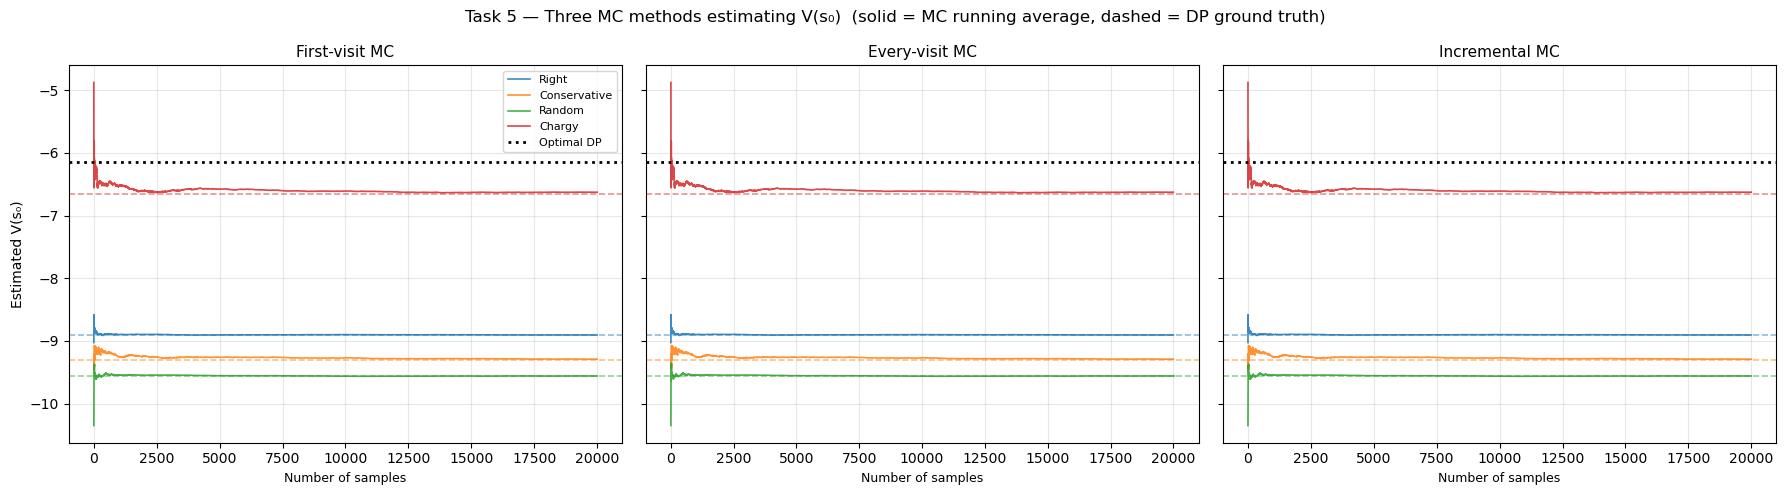

In [130]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles  = ['First-visit MC', 'Every-visit MC', 'Incremental MC']
mc_data = [mc_first, mc_every, mc_incremental]

for ax, title, mc in zip(axes, titles, mc_data):
    for (name, fn), color in zip(policy_fns, colors):
        ax.plot(mc[name], label=name, color=color, lw=1.2, alpha=0.85)
        ax.axhline(policies_dp[name][s0], color=color, lw=1.2, ls='--', alpha=0.5)
    ax.axhline(V_opt[s0], color='black', lw=2, ls=':', label=f'Optimal DP')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Number of samples', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Estimated V(s\u2080)', fontsize=10)
axes[0].legend(fontsize=8)

fig.suptitle('Task 5 — Three MC methods estimating V(s\u2080)  '
             '(solid = MC running average, dashed = DP ground truth)',
             fontsize=12)
plt.tight_layout()
plt.show()


### Discussion — Task 5

**Convergence**: All four MC running averages converge to their DP ground-truth values (dashed lines). After 20 000 episodes, absolute errors are small, validating both the simulator and the DP computations.

**Variance**: The "Random" and "Right" policies exhibit the highest MC variance. "Right" episodes are often very short (quick battery failure $\Rightarrow$ return $= -10$), creating high-variance returns. "Random" has variable episode lengths due to undirected movement.

**Policy ordering**: The ranking $V_{\text{Chargy}} > V_{\text{Conservative}} > V_{\text{Right}} > V_{\text{Random}}$ is preserved under MC, consistent with DP. The optimal DP line (dotted black) lies strictly above all fixed policies, confirming none of them are optimal.

**MC vs DP**: DP gives exact values (up to floating-point precision) when the model is known, while MC is model-free but requires many samples. The close agreement between the two methods provides strong cross-validation of our implementation.

**Observation: Effect of the battery termination condition on policy ranking**

The choice of termination condition — `bat < cost` versus `bat <= cost` — has a surprising effect on the relative performance of the Right and Conservative policies.

Under `bat < cost`, a move that exactly depletes the battery (`bat == cost`) is treated as a successful step that lands at battery level 0. In this regime, the Conservative policy outperforms Right: charging below 50% at a station is genuinely protective, because reaching battery 0 mid-journey is survivable if a station is nearby, and the `-1` charging cost is worth paying to reduce the risk of running out later.

Under `bat <= cost`, that same move fails with a `-10` penalty, making battery 0 a dead state regardless of position. Intuitively this should make Conservative even more valuable — and locally it is, since at states like `(station, 1)` Conservative charges and avoids the guaranteed penalty that Right incurs. However, the global ranking reverses: Right beats Conservative.

The reason is a **threshold mismatch**. The Conservative policy charges when `bat < M/2 = 5`, which means it stops charging at `bat = 5`. But under `bat <= cost`, a step costing exactly 5 from `bat = 5` now also fails — so `bat = 5` is itself a dangerous state. Conservative reaches `bat = 5` and then moves right, having paid charging costs to arrive at a battery level that is still within the danger zone. Right, which never charges, incurs the same failure probability from `bat = 5` but without having wasted steps and discount on charging. The Conservative policy's threshold was implicitly calibrated for the `bat < cost` world, and it no longer provides sufficient protection when the termination condition is stricter.

This highlights a general principle: **the value of a policy depends critically on the environment model**. A policy that is well-tuned under one set of assumptions can become suboptimal — or even counterproductive — when the dynamics change, even subtly.